# Overlay radar + estacoes de superficie + relevo (DEM)

Notebook criado a partir de `notebooks/sumare_radar/exibition_radar.ipynb` e `notebooks/elevation.ipynb` para visualizar as tres fontes na mesma figura ou mapa interativo.


## Dependencias

Descomente as linhas abaixo caso o ambiente nao tenha as bibliotecas instaladas.


In [22]:
# !pip install folium pandas matplotlib pillow pyproj elevation
# !pip install rasterio  # opcional se preferir rasterio em vez de GDAL


## Parametros e caminhos
Ajuste os caminhos se os dados estiverem em outra pasta. O arquivo DEM pode ser gerado com `eio clip` usando os limites do Rio listados abaixo.


In [23]:
from pathlib import Path

# Radar do Sumare
SUMARE_RADAR_LAT = -22.955139
SUMARE_RADAR_LON = -43.248278
SUMARE_RADAR_RADIUS_M = 138_900
RADAR_IMAGE_FILE = Path('../../data/radar_sumare/2019/04/08/2019_04_08_12_52.png')

# Estacoes de superficie (arquivos JSON por sistema)
STATION_SYSTEMS_DIR = Path('../../config/station_systems')

# DEM gerado com a biblioteca elevation (eio clip)
DEM_FILE = Path('../../data/RJ-30m-DEM.tif')
DEM_BOUNDS = (
    -43.8906028271505,  # min lon (oeste)
    -23.1339033365138,  # min lat (sul)
    -43.04835145732227, # max lon (leste)
    -22.649724748272934 # max lat (norte)
)


In [24]:
import json
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LightSource
from math import radians, sin, cos, sqrt, atan2
from osgeo import gdal


def haversine(lat1, lon1, lat2, lon2):
    'Distancia em metros entre dois pares lat/lon.'
    R = 6_371_000
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


def compute_radar_bounds(lat, lon, radius_m):
    radius_km = radius_m / 1000
    deg_lat = radius_km / 111.32
    deg_lon = radius_km / (111.32 * cos(radians(lat)))
    return [[lat - deg_lat, lon - deg_lon], [lat + deg_lat, lon + deg_lon]]


def load_station_systems(directory: Path, state_filter=None) -> pd.DataFrame:
    'Carrega todas as estacoes a partir dos JSONs em config/station_systems.'
    rows = []
    for path in directory.glob("*.json"):
        data = json.loads(path.read_text())
        system = path.stem.upper()
        for sid, meta in data.get("stations", {}).items():
            lat = meta.get("latitude") or meta.get("lat")
            lon = meta.get("longitude") or meta.get("lon")
            if lat is None or lon is None:
                continue
            state = meta.get("state")
            if state_filter and state not in state_filter:
                continue
            rows.append(
                {
                    "station_id": sid,
                    "name": meta.get("name", sid),
                    "system": system,
                    "state": state,
                    "latitude": lat,
                    "longitude": lon,
                }
            )
    return pd.DataFrame(rows)


def load_dem(path):
    if not path.exists():
        raise FileNotFoundError(f'DEM nao encontrado: {path}. Rode "eio clip" para gerar.')

    ds = gdal.Open(str(path))
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray().astype(float)
    nodata = band.GetNoDataValue()
    if nodata is not None:
        arr[arr == nodata] = np.nan

    gt = ds.GetGeoTransform()
    minx, pixel_w, _, maxy, _, pixel_h = gt
    maxx = minx + pixel_w * ds.RasterXSize
    miny = maxy + pixel_h * ds.RasterYSize
    extent = (minx, maxx, miny, maxy)

    return arr, extent, abs(pixel_w), abs(pixel_h)


## Radar + estacoes
Leitura dos arquivos JSON em `config/station_systems/` e calculo dos limites do radar para usar como `bounds` e `extent` nas visualizacoes.


In [25]:
if not RADAR_IMAGE_FILE.exists():
    raise FileNotFoundError(f'Imagem do radar nao encontrada em {RADAR_IMAGE_FILE}')
if not STATION_SYSTEMS_DIR.exists():
    raise FileNotFoundError(f'Diretorio de estacoes nao encontrado em {STATION_SYSTEMS_DIR}')

radar_img = plt.imread(RADAR_IMAGE_FILE)
radar_bounds = compute_radar_bounds(SUMARE_RADAR_LAT, SUMARE_RADAR_LON, SUMARE_RADAR_RADIUS_M)
(lat_min, lon_min), (lat_max, lon_max) = radar_bounds
radar_extent = (lon_min, lon_max, lat_min, lat_max)

stations = load_station_systems(STATION_SYSTEMS_DIR, state_filter={"RJ"})
if stations.empty:
    raise ValueError("Nenhuma estacao carregada. Verifique os arquivos em config/station_systems.")

stations["DIST_RADAR_M"] = stations.apply(
    lambda r: haversine(SUMARE_RADAR_LAT, SUMARE_RADAR_LON, r.latitude, r.longitude), axis=1
)

stations_in_range = stations[stations["DIST_RADAR_M"] <= SUMARE_RADAR_RADIUS_M].copy()
print(f"Estacoes dentro do raio de cobertura: {len(stations_in_range)}")
stations_in_range.head()


Estacoes dentro do raio de cobertura: 54


,station_id,name,system,state,latitude,longitude,DIST_RADAR_M
0,alto_da_boa_vista,Alto da Boa Vista,ALERTARIO,RJ,-22.9658,-43.2783,3294.484617
1,anchieta,Anchieta,ALERTARIO,RJ,-22.8269,-43.4033,21342.738610
2,av_brasil_mendanha,Av. Brasil/Mendanha,ALERTARIO,RJ,-22.8569,-43.5411,31920.085061
3,bangu,Bangu,ALERTARIO,RJ,-22.8803,-43.4658,23781.614807
4,barrinha,Barra/Barrinha,ALERTARIO,RJ,-23.0085,-43.2997,7931.968301


## DEM e hillshade
Carrega o raster de relevo gerado via `elevation`, calcula o hillshade e guarda o `extent` para plot.


In [26]:
dem, dem_extent, pixel_w, pixel_h = load_dem(DEM_FILE)

ls = LightSource(azdeg=315, altdeg=45)
dem_filled = np.where(np.isnan(dem), np.nanmean(dem), dem)
hillshade = ls.hillshade(dem_filled, vert_exag=1.5, dx=pixel_w, dy=pixel_h)

print(f"DEM carregado: shape={dem.shape}, extent={dem_extent}")


DEM carregado: shape=(1743, 3032), extent=(-43.89069444444445, -43.04847222222223, -23.133750000000003, -22.649583333333336)


## Figura estatica (matplotlib)
Sobrepoe hillshade + dem (cmap terrain) + imagem do radar + pontos das estacoes.


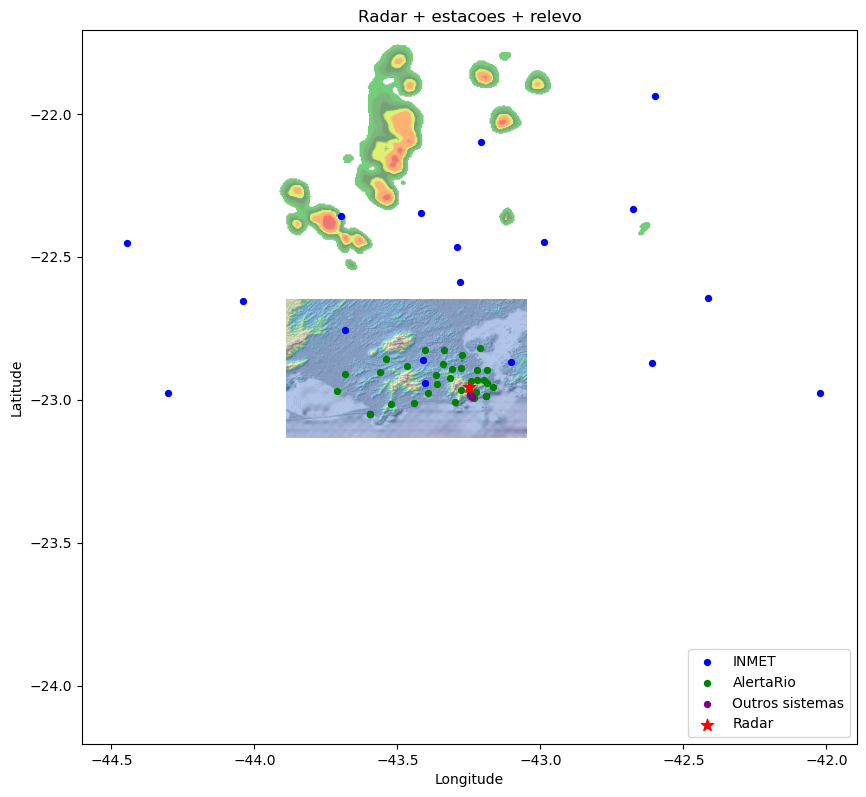

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(hillshade, cmap="gray", extent=dem_extent, origin="upper", alpha=0.55)
ax.imshow(dem, cmap="terrain", extent=dem_extent, origin="upper", alpha=0.35)
ax.imshow(radar_img, extent=radar_extent, origin="upper", alpha=0.55)

inmet = stations_in_range[stations_in_range.system == "INMET"]
alr = stations_in_range[stations_in_range.system == "ALERTARIO"]
others = stations_in_range[~stations_in_range.system.isin(["INMET", "ALERTARIO"])]

ax.scatter(inmet.longitude, inmet.latitude, s=18, c="blue", label="INMET")
ax.scatter(alr.longitude, alr.latitude, s=18, c="green", label="AlertaRio")
if not others.empty:
    ax.scatter(others.longitude, others.latitude, s=18, c="purple", label="Outros sistemas")
ax.scatter(SUMARE_RADAR_LON, SUMARE_RADAR_LAT, marker="*", c="red", s=80, label="Radar")

ax.set_title("Radar + estacoes + relevo")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right")
ax.set_xlim(radar_extent[0], radar_extent[1])
ax.set_ylim(radar_extent[2], radar_extent[3])
plt.show()


## Mapa interativo (folium)
Cria um mapa com controles de camada para DEM, radar e estacoes.



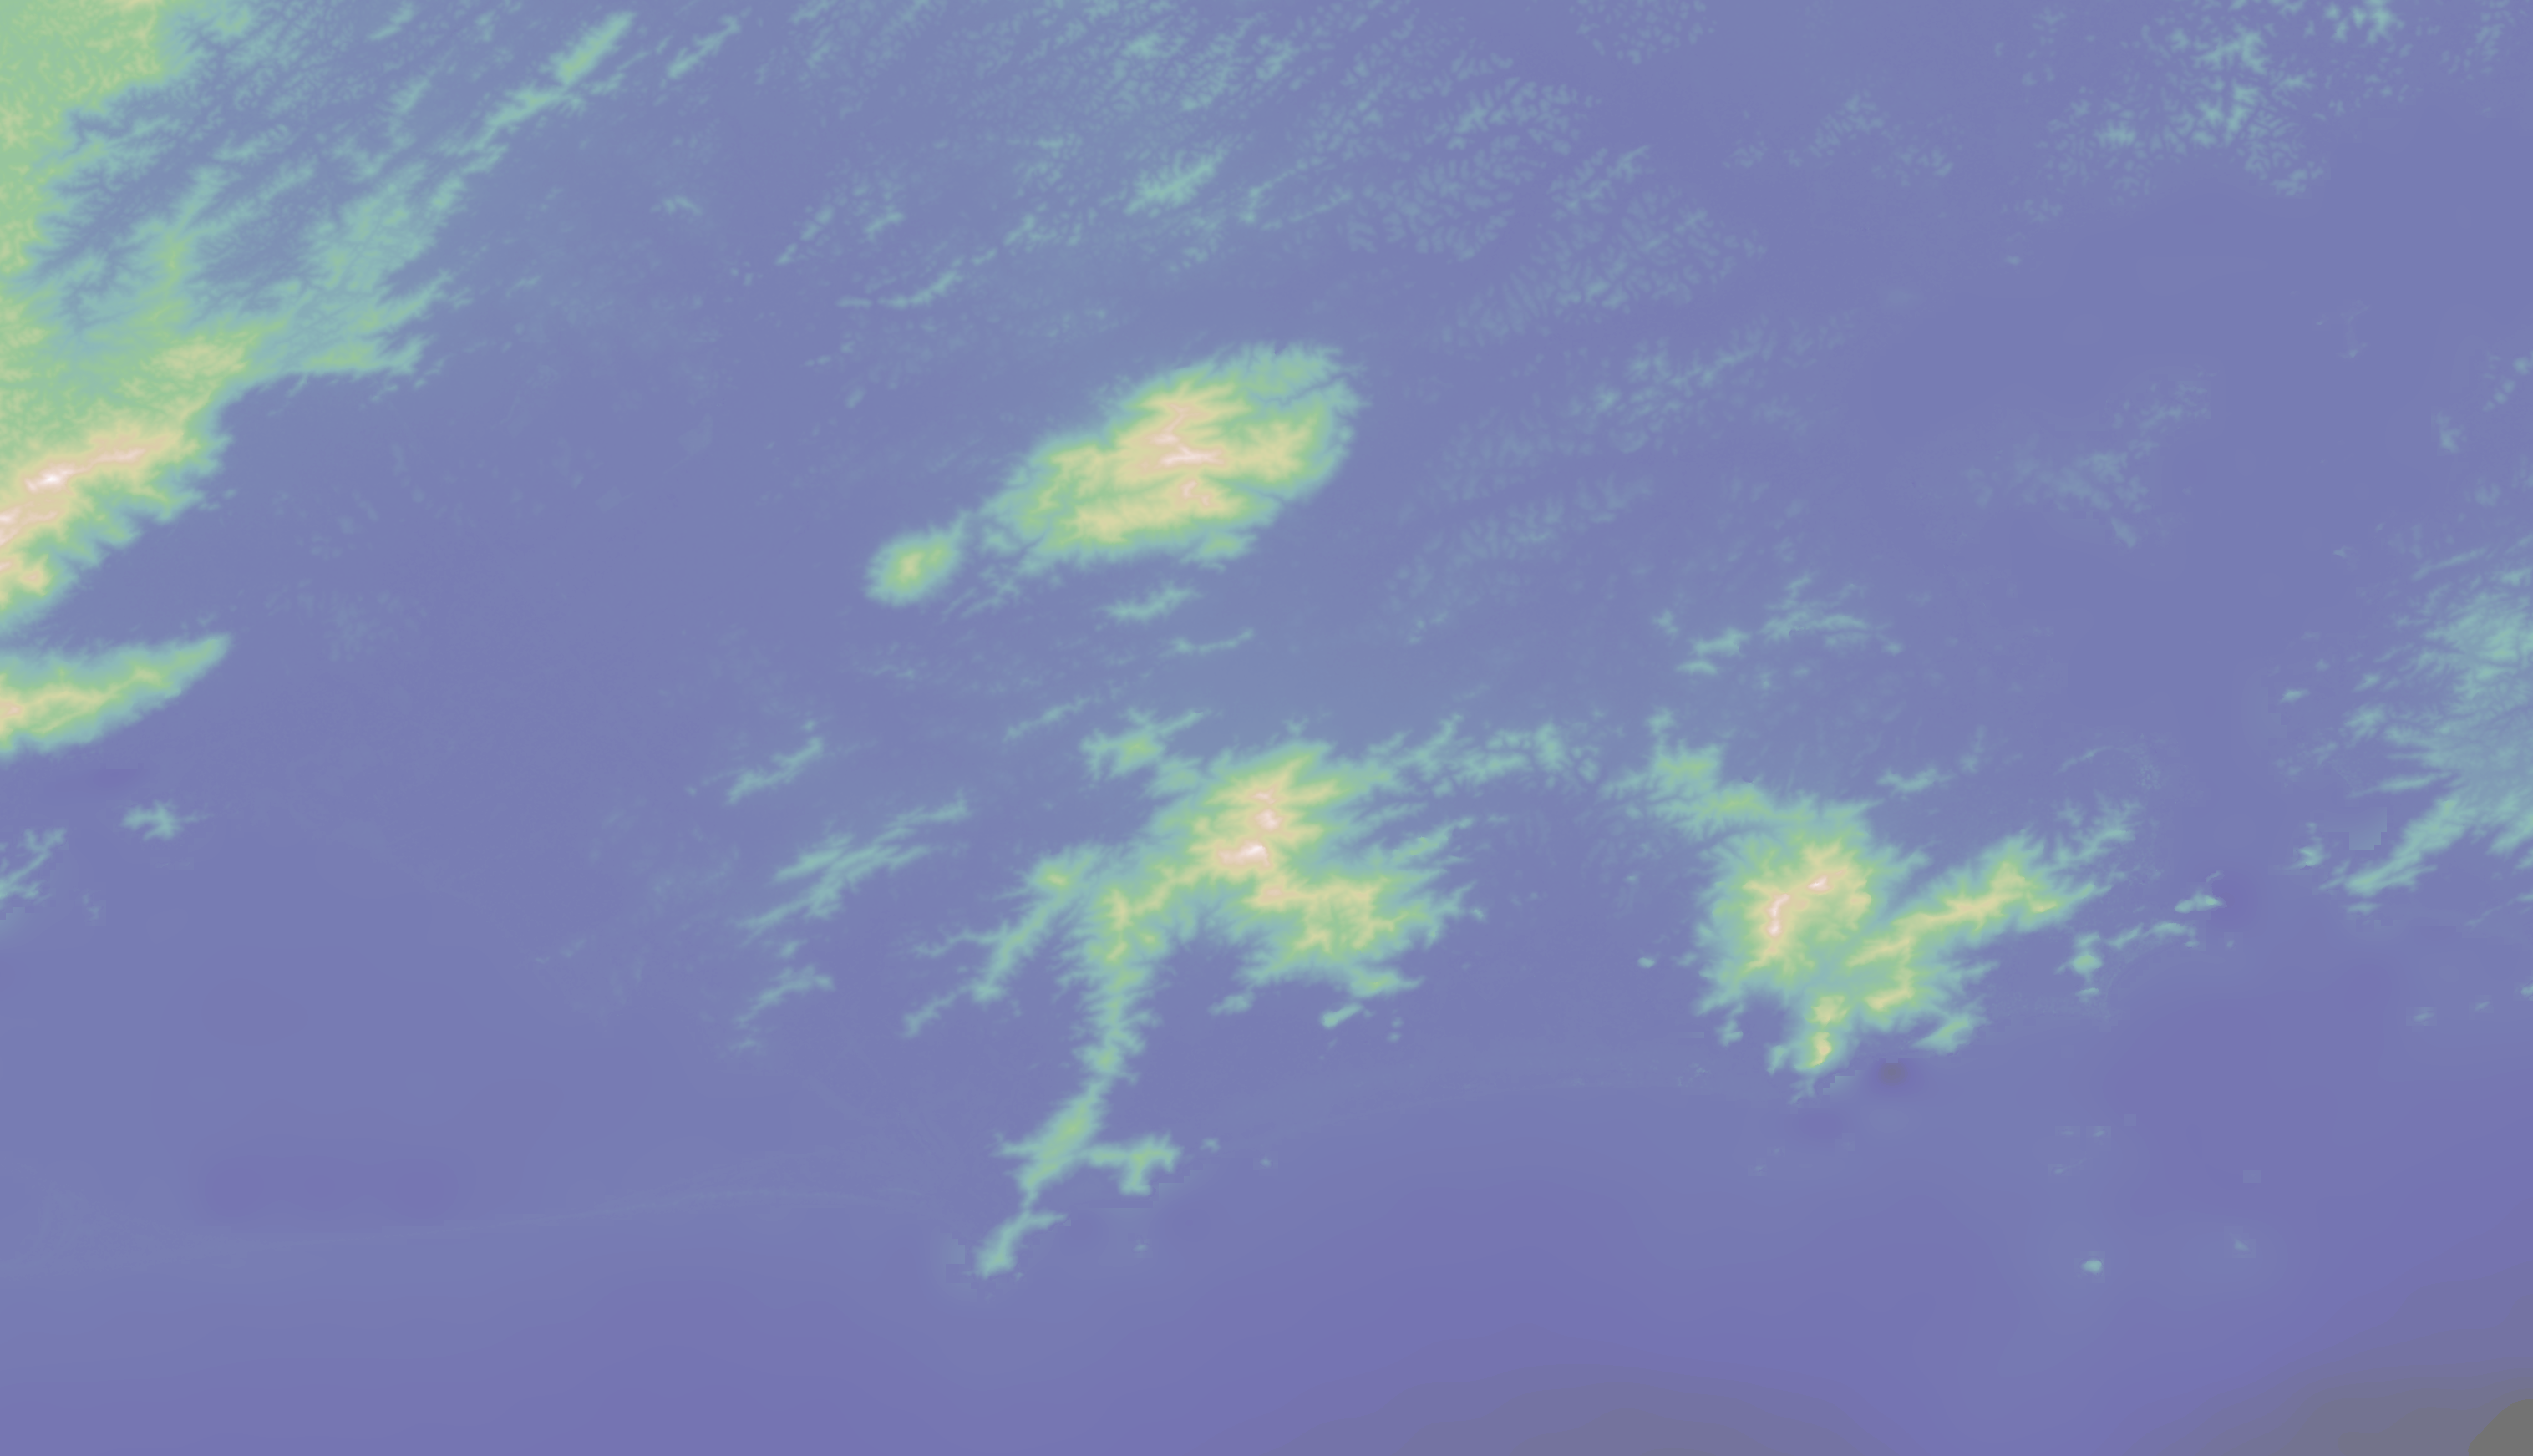
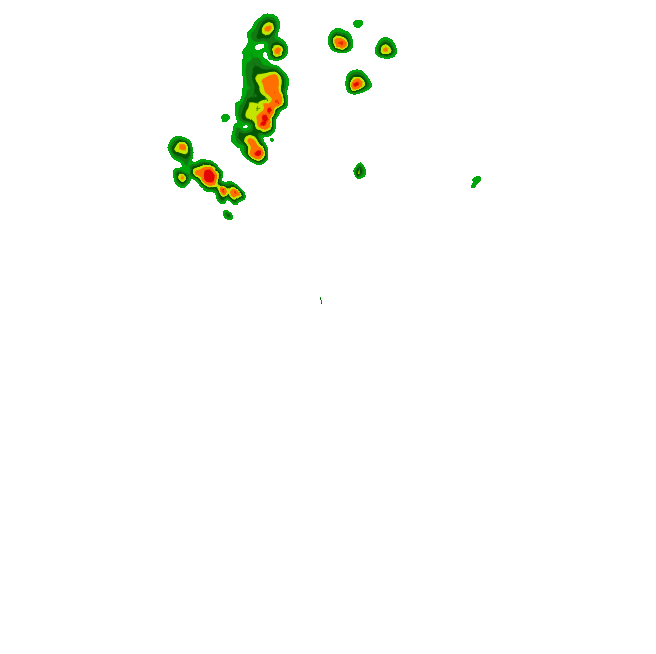

In [28]:
dem_norm = (dem - np.nanmin(dem)) / (np.nanmax(dem) - np.nanmin(dem))
dem_norm = np.clip(dem_norm, 0, 1)
dem_rgba = cm.gist_earth(dem_norm)
dem_rgba[..., 3] = 0.55
dem_rgba[np.isnan(dem_norm)] = (0, 0, 0, 0)
dem_overlay = (dem_rgba * 255).astype(np.uint8)

dem_bounds_for_folium = [[dem_extent[2], dem_extent[0]], [dem_extent[3], dem_extent[1]]]

m = folium.Map(location=[SUMARE_RADAR_LAT, SUMARE_RADAR_LON], zoom_start=9, tiles='cartodbpositron')

folium.raster_layers.ImageOverlay(
    image=dem_overlay,
    bounds=dem_bounds_for_folium,
    name="Relevo (DEM)",
    opacity=1,
    origin="upper",
).add_to(m)

folium.raster_layers.ImageOverlay(
    image=str(RADAR_IMAGE_FILE),
    bounds=[[lat_min, lon_min], [lat_max, lon_max]],
    name="Radar Sumare",
    opacity=0.6,
).add_to(m)

layer_inmet = folium.FeatureGroup(name="Estacoes INMET", show=True)
layer_alerta = folium.FeatureGroup(name="Estacoes AlertaRio", show=True)
layer_others = folium.FeatureGroup(name="Outras estacoes", show=True)

color_by_system = {
    "INMET": "blue",
    "ALERTARIO": "green",
}

for _, row in stations_in_range.iterrows():
    lat, lon = row.latitude, row.longitude
    name = row.get("name", "Estacao")
    system = row.get("system", "")
    color = color_by_system.get(system, "purple")

    marker = folium.CircleMarker(
        location=[lat, lon],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.9,
        popup=f"<b>{name}</b><br>Sistema: {system}<br>({lat:.4f}, {lon:.4f})",
    )

    if system == "INMET":
        marker.add_to(layer_inmet)
    elif system == "ALERTARIO":
        marker.add_to(layer_alerta)
    else:
        marker.add_to(layer_others)

layer_inmet.add_to(m)
layer_alerta.add_to(m)
layer_others.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)

m


## Gerar o DEM com elevation
Use esta célula apenas se precisar baixar o DEM novamente. Altere o caminho de saída se necessário.


In [29]:
# !eio clip -o ../../data/RJ-30m-DEM.tif --bounds
#     -43.8906028271505 -23.1339033365138 -43.04835145732227 -22.649724748272934

In [30]:
# Funcao para obter altitude (m) no ponto de uma estacao

def altitude_at(lat: float, lon: float, dem_array=dem, dem_extent=dem_extent, pixel_w=None, pixel_h=None):
    "Retorna a altitude estimada (em metros) para lat/lon usando o DEM carregado."
    minx, maxx, miny, maxy = dem_extent
    if not (miny <= lat <= maxy and minx <= lon <= maxx):
        raise ValueError("Ponto fora da area do DEM")

    # Pixel size (usa os valores retornados pelo load_dem, se disponiveis)
    if pixel_w is None or pixel_h is None:
        px_w = (maxx - minx) / dem_array.shape[1]
        px_h = (maxy - miny) / dem_array.shape[0]
    else:
        px_w, px_h = pixel_w, pixel_h

    col = int((lon - minx) / px_w)
    row = int((maxy - lat) / px_h)  # origem superior

    if row < 0 or row >= dem_array.shape[0] or col < 0 or col >= dem_array.shape[1]:
        raise ValueError("Indice fora dos limites do raster")

    return float(dem_array[row, col])

# Exemplo: usa a primeira estacao dentro do alcance
if not stations_in_range.empty:
    sample_row = stations_in_range.iloc[0]
    alt = altitude_at(sample_row.latitude, sample_row.longitude)
    print(f"Altitude para {sample_row.station_id} ({sample_row.system}): {alt:.2f} m")


Altitude para alto_da_boa_vista (ALERTARIO): 354.00 m
